# SMARTS test + ACT bond perception

This notebook uses ACT's `get_mol_dict.py` + `atom_bond.xml` to read XYZ/PDB/SDF, determine bonds with ACT logic, and test SMARTS pattern against the molecule quite easily. \
You can also use nother atom_bond.xml by copying it in the CWD of the notebook, `get_mol_dict.py` will prioritize it.


In [4]:
from pathlib import Path
import os, sys
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, rdDepictor, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image
from get_mol_dict import MoleculeDict, get_atom_bond_xml

os.environ['ACTDATA'] = str(Path('../..') / 'share')


Define your input file and charge here.

In [5]:
# Config
input_path = Path('1-methyl-adenine.xyz')  
mycharge = 0 

Get ACT to create your moleucles mol.

In [6]:
# Run using ACT logic
abe = get_atom_bond_xml()

md = MoleculeDict(verbose=False)
success = md.read(input_path.stem, str(input_path), input_path.suffix.lstrip('.'), mycharge)
if not success:
    raise RuntimeError('MoleculeDict.read() failed')

mol = getattr(md, 'mol', None)
if mol is None:
    raise RuntimeError('MoleculeDict did not expose RDKit mol for display')

formula = rdMolDescriptors.CalcMolFormula(mol)
print(f'Title: {md.title}')
print(f'Formula: {formula}')
print(f'Atoms: {mol.GetNumAtoms()}  Bonds: {mol.GetNumBonds()}')


Title: 1-methyl-adenine
Formula: C6H7N5
Atoms: 18  Bonds: 19


Define your SMART to test and test it!

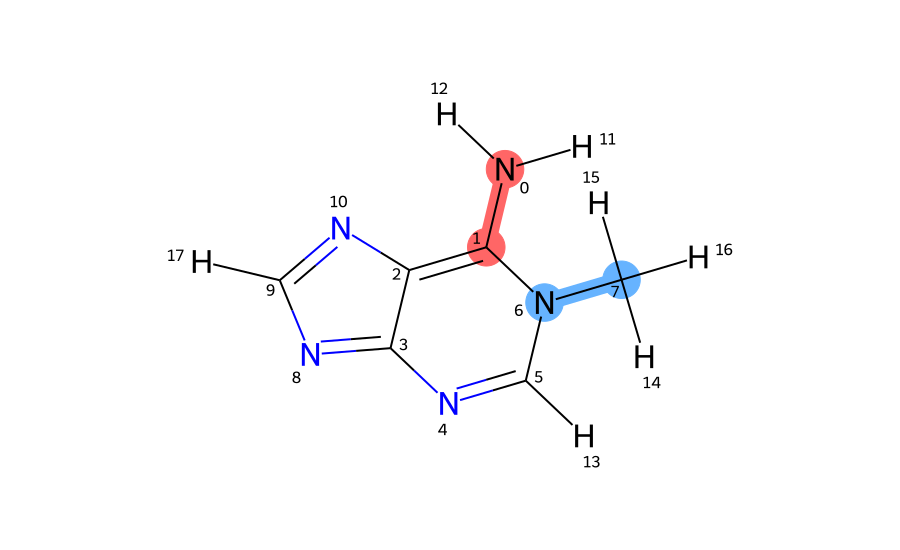

SMARTS: [#7]-[#6]
Matches found: 2
  Match 1 (red): atoms [0, 1]
  Match 2 (blue): atoms [6, 7]


In [7]:
# SMARTS test
smarts_to_test = '[#7]-[#6]'

pattern = Chem.MolFromSmarts(smarts_to_test)
if pattern is None:
    raise ValueError(f'Invalid SMARTS: {smarts_to_test}')

matches = mol.GetSubstructMatches(pattern)
#print(matches)
if not matches:
    print("No matches found.")
else:
    # Per-match coloring
    palette = [
        (1.0, 0.4, 0.4),   # red
        (0.4, 0.7, 1.0),   # blue
        (0.4, 1.0, 0.5),   # green
        (1.0, 0.8, 0.2),   # yellow
        (0.9, 0.5, 1.0),   # purple
        (1.0, 0.65, 0.2),  # orange
    ]

    atom_color_map = {}
    bond_color_map = {}
    highlight_atoms = []
    highlight_bonds = []

    for match_idx, mt in enumerate(matches):
        #print(mt)
        color = palette[match_idx % len(palette)]

        for atom_idx in mt:
            if atom_idx not in atom_color_map:
                highlight_atoms.append(atom_idx)
            atom_color_map[atom_idx] = color

        if pattern.GetNumBonds() > 0:
            for pbond in pattern.GetBonds():
                ai = mt[pbond.GetBeginAtomIdx()]
                aj = mt[pbond.GetEndAtomIdx()]
                b = mol.GetBondBetweenAtoms(ai, aj)
                if b is not None:
                    bidx = b.GetIdx()
                    if bidx not in bond_color_map:
                        highlight_bonds.append(bidx)
                    bond_color_map[bidx] = color

    mol2d = Chem.RWMol(Chem.Mol(mol))
    rdDepictor.Compute2DCoords(mol2d)

    # atom index labels
    for atom in mol2d.GetAtoms():
        atom.SetProp('atomNote', str(atom.GetIdx()))

    # draw
    drawer = rdMolDraw2D.MolDraw2DCairo(900, 550)
    opts = drawer.drawOptions()
    opts.addAtomIndices = False          
    opts.highlightBondWidthMultiplier = 8   
    opts.highlightRadius = 0.35             
    opts.padding = 0.15

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol2d,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_color_map,
        highlightBonds=highlight_bonds,
        highlightBondColors=bond_color_map,
    )
    drawer.FinishDrawing()
    display(Image(drawer.GetDrawingText()))
    
    # match summary
    print(f"SMARTS: {smarts_to_test}")
    print(f"Matches found: {len(matches)}")
    for i, mt in enumerate(matches):
        color_name = ["red","blue","green","yellow","purple","orange"][i % 6]
        print(f"  Match {i+1} ({color_name}): atoms {list(mt)}")

